# pRF analysis - binning
This notebook plots the properties of pRFs vs. eccentricity

In [19]:
import cortex
import cortex.polyutils
import sys
import numpy as np
import yaml
import os
opj = os.path.join
from prfpy.fit import Iso2DGaussianFitter, Fitter, Extend_Iso2DGaussianFitter
import neuropythy
from neuropythy import as_retinotopy
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import cortex
from scipy import stats
import seaborn as sns
pio.renderers.default="png"
list(pio.renderers)
import sys
import pickle
from numpy.polynomial import Polynomial

In [20]:
subjectid='sub-34'
subject = 'sub-34'
atlas = 'manual'
roi=['all']
project='PROJECT_EGRET-AAA'
denoising='nordic'
MAIN_PATH=f'/Volumes/FedericaCardillo/pre-processing/projects/{project}/derivatives'
test_file=opj(f'/Volumes/FedericaCardillo/pre-processing/projects/{project}/derivatives/pRFM/{subjectid}/ses-02/{denoising}/mirrored/', f'model-{atlas}-nelder-mead-GM_desc-prf_params_random.pkl')
depth='GM'
fssubject = 'fsnative'
model_name='gauss_fitter'
space='fsnative'
roi=['all']

# In order to get the number of vertices in this subject's cortical surface
# we have to load in their surfaces and get the number of points in each
surfs = [cortex.polyutils.Surface(*d) for d in cortex.db.get_surf(subject, "fiducial")]
# First we need to import the surfaces for this subject
numel_left = surfs[0].pts.shape[0]
numel_right = surfs[1].pts.shape[0]
numel = numel_left + numel_right
depth_list=[1]

In [21]:
# Plot fit results
test_file=opj(f'/Volumes/FedericaCardillo/pre-processing/projects/{project}/derivatives/pRFM/{subjectid}/ses-02/{denoising}/', f'model-{atlas}-nelder-mead-GM_desc-prf_params.pkl')

with open(test_file, 'rb') as input:
    pkl_data = pickle.load(input)

prf_params=[np.array([])]
prf_params_vx=[np.array([])]

roi_verts=np.where(pkl_data['rois_mask']==1)
for d in range(depth_list.__len__()):
    prf_params[d]=pkl_data['model'].iterative_search_params
    prf_params_vx[d]=roi_verts[0]

In [22]:
class pRFmodel:
    def __init__(self, r2, pRFsize, pRFcenter_ecc, pRFcenter_angle):
        self.r2 = r2
        self.pRFsize = pRFsize
        self.pRFcenter_ecc = pRFcenter_ecc
        self.pRFcenter_angle = pRFcenter_angle

pRFmodel = [pRFmodel([], [], [], [])]
for d in range(depth_list.__len__()):
    pRFmodel[d].pRFcenter_ecc = np.sqrt(prf_params[d][:,1]**2+prf_params[d][:,0]**2)
    pRFmodel[d].pRFcenter_angle = np.rad2deg(np.arctan2(prf_params[d][:,1],prf_params[d][:,0]))
    pRFmodel[d].pRFsize = prf_params[d][:,2]
    pRFmodel[d].r2 = prf_params[d][:,7]

In [23]:
# for d in range(depth_list.__len__()):
#     plt.hist(pRFmodel[d].pRFsize[pRFmodel[d].r2>-1], alpha=0.5)
# data = [pRFmodel[0].pRFsize[pRFmodel[0].r2>-1]]

# fig = plt.figure(figsize =(10, 7))
# ax = fig.add_axes([0, 0, 1, 1])
# bp = ax.boxplot(data)

In [24]:
# Select ROIs

fs_dirPATH=f'{MAIN_PATH}/freesurfer' 
subject=subjectid
hemi=['RH','LH']

idx_rois1, idx_vls1 = cortex.freesurfer.get_label(subject, label='benson14_eccen-0001', fs_dir=fs_dirPATH, hemisphere=('lh', 'rh'), verbose=True)
idx_rois4, idx_vls4 = cortex.freesurfer.get_label(subject, label='benson14_varea-0001',fs_dir=fs_dirPATH, hemisphere=('lh', 'rh'), verbose=True)

if atlas=='manual':
    idx_rois1, idx_vls1 = cortex.freesurfer.get_label(subject, label='benson14_eccen-0001', fs_dir=fs_dirPATH, hemisphere=('lh', 'rh'), verbose=True)
    idx_rois5, idx_vls5 = cortex.freesurfer.get_label(subject, label='manualdelin', fs_dir=fs_dirPATH, hemisphere=('lh','rh'), verbose=True)
    idx_vls4[idx_rois5]=idx_vls5

looking for ['/Volumes/FedericaCardillo/pre-processing/projects/PROJECT_EGRET-AAA/derivatives/freesurfer/sub-34/label/lh.benson14_eccen-0001.label', '/Volumes/FedericaCardillo/pre-processing/projects/PROJECT_EGRET-AAA/derivatives/freesurfer/sub-34/label/rh.benson14_eccen-0001.label']
looking for ['/Volumes/FedericaCardillo/pre-processing/projects/PROJECT_EGRET-AAA/derivatives/freesurfer/sub-34/label/lh.benson14_varea-0001.label', '/Volumes/FedericaCardillo/pre-processing/projects/PROJECT_EGRET-AAA/derivatives/freesurfer/sub-34/label/rh.benson14_varea-0001.label']
looking for ['/Volumes/FedericaCardillo/pre-processing/projects/PROJECT_EGRET-AAA/derivatives/freesurfer/sub-34/label/lh.benson14_eccen-0001.label', '/Volumes/FedericaCardillo/pre-processing/projects/PROJECT_EGRET-AAA/derivatives/freesurfer/sub-34/label/rh.benson14_eccen-0001.label']
looking for ['/Volumes/FedericaCardillo/pre-processing/projects/PROJECT_EGRET-AAA/derivatives/freesurfer/sub-34/label/lh.manualdelin.label', '/Vo

0.5305255891486492
0.5933202942806282
0.578027263073399


/var/folders/0k/zjsxn2197mdbzvx14lj8m0v00000gn/T/ipykernel_46182/3962793695.py:49: RuntimeWarning:

Mean of empty slice



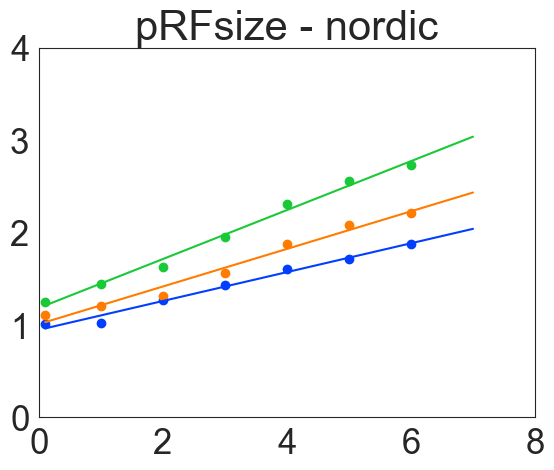

In [25]:
list_prop=["pRFcenter_ecc","pRFcenter_angle","pRFsize","r2"]
prop=list_prop[2]
rois_list = []
rois_list = np.array([['V1','V2', 'V3'], [1, 2, 3]])
rois = [['V1','V2', 'V3']]

for r in range(rois[0].__len__()):
    for d in range(depth_list.__len__()):
        pRFmodel[d].pRFcenter_ecc = np.sqrt(prf_params[d][:,1]**2+prf_params[d][:,0]**2)
        pRFmodel[d].pRFcenter_angle = np.rad2deg(np.arctan2(prf_params[d][:,1],prf_params[d][:,0]))
        pRFmodel[d].pRFsize = prf_params[d][:,2]
        pRFmodel[d].r2 = prf_params[d][:,7]
    roi=rois[0][r]
    roi_idx = np.where(roi == rois_list[0, :])
    roi_verts = np.array(np.where(idx_vls4 == int(rois_list[1, roi_idx])))[0]
    idx=np.in1d(prf_params_vx[0],roi_verts)

    for d in range(depth_list.__len__()):
        pRFmodel[d].pRFcenter_ecc = pRFmodel[d].pRFcenter_ecc[idx==True]
        pRFmodel[d].pRFcenter_angle = pRFmodel[d].pRFcenter_angle[idx==True]
        pRFmodel[d].pRFsize = pRFmodel[d].pRFsize[idx==True]
        pRFmodel[d].r2 = pRFmodel[d].r2[idx==True]

    q1=np.percentile(pRFmodel[0].r2,25)
    q3=np.percentile(pRFmodel[0].r2,75)
    print(q3)
    thr=0.3
    idx_r2=pRFmodel[0].r2>thr
    idx_ecc1=pRFmodel[0].pRFcenter_ecc>0
    idx_ecc2=pRFmodel[0].pRFcenter_ecc<7
    idx_size = pRFmodel[0].pRFsize > 0.1 # I added it from Mayra's script
    # idx_thr=np.where(np.logical_and(np.logical_and(idx_r2,idx_ecc1),idx_ecc2)) It was like this in Mayra's script 
    idx_thr=np.where(np.logical_and(np.logical_and(np.logical_and(idx_r2, idx_ecc1), idx_ecc2), idx_size)) # I added it from Mayra's script
    if (r==0):
        data=[getattr(pRFmodel[0],prop)[idx_thr]]
    else:
        data.extend([getattr(pRFmodel[0],prop)[idx_thr]])
    ecc = [getattr(pRFmodel[0],"pRFcenter_ecc")[idx_thr]]
    getattr(pRFmodel[0],prop)[pRFmodel[0].r2>thr]
    
    # Plotting
    plt.title(label=prop+" - "+denoising)
    plt.ylim([0,1])
    plt.figure(1)
    bins = np.array([0.1, 1, 2, 3, 4, 5, 6, 7])
    inds = np.digitize(ecc, bins)
    mean = np.zeros(len(bins))
    for i in range(len(bins)):
        mean[i]=np.nanmean(data[r][inds[0]==i+1])
    plt.scatter(bins, mean)
        
    # Fit and plot the trend line.
    idx = np.isfinite(mean)
    model = np.polyfit(bins[idx], mean[idx], deg=1)
    predict = np.poly1d(model)
    x_line = np.linspace(bins.min(), bins.max(), 100)
    y_line=predict(x_line)
    plt.plot(x_line,y_line)
    plt.xlim([0,8])
    plt.ylim([0,4])

plt.show()
# plt.boxplot(data)
# if prop=='r2':
#     plt.ylim([0,1])
# else:
#     plt.ylim([0,5])
# plt.rc('font',size=25)

0.5305255891486492
0.5933202942806282
0.578027263073399


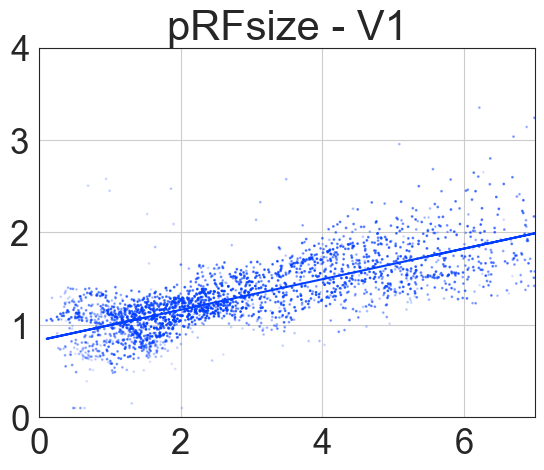

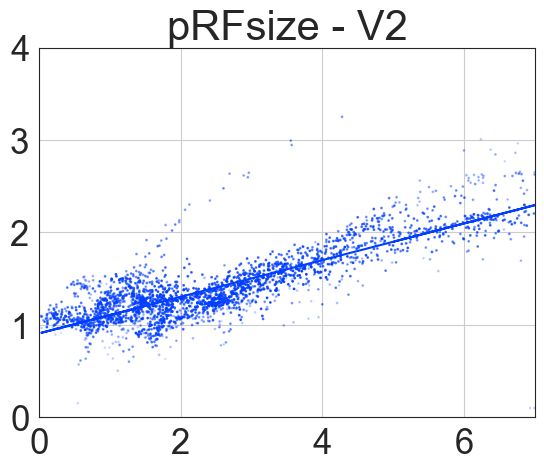

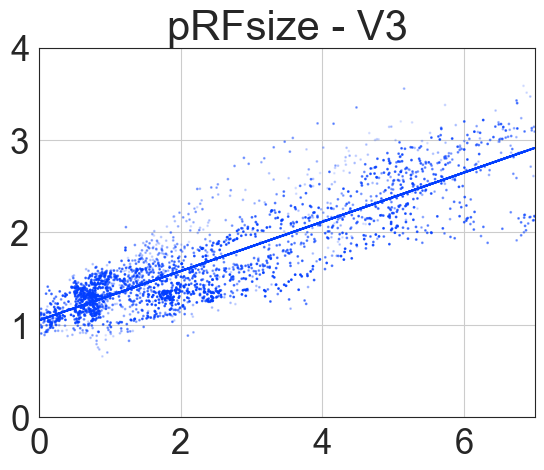

In [26]:
list_prop=["pRFcenter_ecc","pRFcenter_angle","pRFsize","r2"]
prop=list_prop[2]
rois_list = []
rois_list = np.array([['V1','V2', 'V3'], [1, 2, 3]])
rois = [['V1','V2', 'V3']]

for r in range(rois[0].__len__()):
    for d in range(depth_list.__len__()):
        pRFmodel[d].pRFcenter_ecc = np.sqrt(prf_params[d][:,1]**2+prf_params[d][:,0]**2)
        pRFmodel[d].pRFcenter_angle = np.rad2deg(np.arctan2(prf_params[d][:,1],prf_params[d][:,0]))
        pRFmodel[d].pRFsize = prf_params[d][:,2]
        pRFmodel[d].r2 = prf_params[d][:,7]
    roi=rois[0][r]
    roi_idx = np.where(roi == rois_list[0, :])
    roi_verts = np.array(np.where(idx_vls4 == int(rois_list[1, roi_idx])))[0]
    idx=np.in1d(prf_params_vx[0],roi_verts)

    for d in range(depth_list.__len__()):
        pRFmodel[d].pRFcenter_ecc = pRFmodel[d].pRFcenter_ecc[idx==True]
        pRFmodel[d].pRFcenter_angle = pRFmodel[d].pRFcenter_angle[idx==True]
        pRFmodel[d].pRFsize = pRFmodel[d].pRFsize[idx==True]
        pRFmodel[d].r2 = pRFmodel[d].r2[idx==True]

    q1=np.percentile(pRFmodel[0].r2,25)
    q3=np.percentile(pRFmodel[0].r2,75)
    print(q3)
    thr=0.3
    idx_r2=pRFmodel[0].r2>thr
    idx_ecc1=pRFmodel[0].pRFcenter_ecc>0
    idx_ecc2=pRFmodel[0].pRFcenter_ecc<7
    idx_size = pRFmodel[0].pRFsize > 0.1
    idx_thr=np.where(np.logical_and(np.logical_and(np.logical_and(idx_r2, idx_ecc1), idx_ecc2), idx_size)) # I added it from Mayra's script
    if (r==0):
        data=[getattr(pRFmodel[0],prop)[idx_thr]]
    else:
        data.extend([getattr(pRFmodel[0],prop)[idx_thr]])

    ecc = [getattr(pRFmodel[0],"pRFcenter_ecc")[idx_thr]]
    getattr(pRFmodel[0],prop)[pRFmodel[0].r2>thr]

    # Weigthed based on the r2 values 
    r2_values = pRFmodel[0].r2[idx_thr] 
    alpha = (r2_values - np.min(r2_values)) / (np.max(r2_values) - np.min(r2_values)) 
    alpha = 0.1 + 0.9 * alpha
    
    # Creating plot
    plt.figure(r)
    plt.title(label=prop+" - "+rois_list[0][r])
    plt.xlim([0,7])
    if prop=='r2':
        plt.ylim([0,1])
    else:
        plt.ylim([0,4])
    plt.rc('font',size=25)
    plt.scatter(ecc,data[r], alpha=alpha, s=1)
    # Fit and plot the trend line.
    model= np.polyfit(ecc[0][:],data[r], deg=1)
    predict = np.poly1d(model)
    x_line=ecc[0][:]
    y_line=predict(x_line)
    plt.plot(x_line,y_line)
    plt.grid(True)
plt.show()

# plt.boxplot(data)
# if prop=='r2':
#     plt.ylim([0,1])
# else:
#     plt.ylim([0,5])
# plt.rc('font',size=25)

In [27]:
from prfpy.rf import gauss2D_iso_cart
from marcus_prf_eg.plot_functions import *
from prfpy.stimulus import PRFStimulus2D
import scipy.io

rsq_idx = prf_params[0][:,-1] >0.79
rsq_idx = np.where(rsq_idx)[0][0:10]
for i_vx in rsq_idx:
    TR_s = pkl_data['settings']['TR']
    fig = plt.figure(constrained_layout=True, figsize=(30,10))
    subfigs = fig.subfigures(1, 2, width_ratios=[10,30])
    #i_vx = 0
    #i_vx=11184

    #load dm
    dm =scipy.io.loadmat(f'{MAIN_PATH}/pRFM/sub-001/ses-1/design_task-ret.mat')['stim']
    #load psc
    psc_avg_ts_full=np.load(f'{MAIN_PATH}/pRFM/{subject}/ses-1/{denoising}/{subject}_ses-1_task-ret_hemi-LR_desc-avg_bold_{depth}.npy').T[:,:]
    print(psc_avg_ts_full.shape)

    if psc_avg_ts_full.shape[1]>225:
        psc_avg_ts_full=psc_avg_ts_full[:,:225]

    print(psc_avg_ts_full.shape)
    psc_avg_ts=psc_avg_ts_full[pkl_data['rois_mask']==1]
    print(psc_avg_ts.shape)

    #load prf_stim
    prf_stim = PRFStimulus2D(
        screen_size_cm=pkl_data['settings']['screen_size_cm'],          # Distance of screen to eye
        screen_distance_cm=pkl_data['settings']['screen_distance_cm'],  # height of the screen (i.e., the diameter of the stimulated region)
        design_matrix=dm,                                   # dm (npix x npix x time_points)
        TR=pkl_data['settings']['TR'],                                  # TR
        )

    # ************* TIME COURSE PLOT *************
    time_pts = np.arange(psc_avg_ts.shape[1]) * TR_s
    ax2 = subfigs[1].add_subplot()
    ax2.plot(time_pts, psc_avg_ts[i_vx,:], '-+k', label= 'data')
    ax2.plot(time_pts, pkl_data['pred_tc'][i_vx,:], '-*r', label= 'pred')
    # ax2.plot(time_pts, pred_tc_nohrf[i_vx,:], '-*b', label= 'pred_nohrf')
    ax2.set_xlabel('time (s)')
    ax2.legend()
    ax2.set_ylim([-10,30])
    plt.rcParams.update({'font.size': 22})

    gauss_param_name = ['x', 'y', 'size', 'beta', 'baseline', 'hrf_der','hrf_disp','rsq']
    title_txt = ''
    for i,p in enumerate(gauss_param_name):
        title_txt += f'{p}={prf_params[0][i_vx,i]:.3f},'
    ax2.set_title(title_txt)

    # ********* PRF PLOT **********
    rf = gauss2D_iso_cart(
        x=prf_stim.x_coordinates,
        y=prf_stim.y_coordinates,
        mu=(prf_params[0][i_vx,0], prf_params[0][i_vx,1]),
        sigma=prf_params[0][i_vx,2])
    ax1 = subfigs[0].add_subplot()
    ax1.imshow(rf, vmin=0, vmax=1, extent=[-5,5,-5,5])
    ax1.axis('off')

    time_pt = 90
    if time_pt != None:
        ax1.imshow(dm[:,:,time_pt], vmin=0, vmax=1,cmap='Greys', alpha=0.1, extent=[-5,5,-5,5])
        ax_lim = ax2.get_ylim()
        ax2.plot((time_pt*TR_s, time_pt*TR_s), (ax_lim), '--g')

    ax2.set_xticks(np.arange(time_pts[0], time_pts[-1],50))
    plt.rc('axes', labelsize=22)    # fontsize of the x and y labels
    plt.rc('xtick', labelsize=22)
    add_dm_to_ts(fig, ax2, dm, TR=TR_s, dx_axs=2)

x: [6.87356222 6.27178955 6.80427661 ... 1.53401353 1.73398188 0.75659556]
x shape: (2292,)
y: [2.02348824 2.06052641 2.10970353 ... 1.36491299 1.54160638 1.32996377]
y shape: (2292,)
r2: [0.52122511 0.52576935 0.52046919 ... 0.55212694 0.45502493 0.70775897]
r2 shape: (2292,)


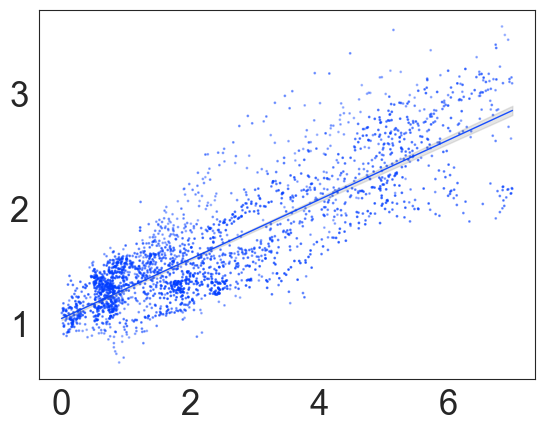

In [28]:
def bs_scatter2weightedavg(x ,y , r2, N, cf, ecc_bound, x_pred_point=None): # N: number of bootstrapped samples, cf: confidence level
    sns.set_palette('bright')  # Use 'mako' color palette from Seaborn
    sns.set_style('white')  # Set the style with grid
    colors=sns.color_palette()
    bs_beta, bs_a=[], []
    indices = np.argsort(x) #reorder elements of x in ascending order
    x, y, r2 =x[indices], y[indices], r2[indices]
    x_fit = np.linspace(ecc_bound[0],ecc_bound[1],len(x)) # Points for new predictions
    y_fit = np.zeros((N, len(x_fit))) # Initialize a matrix to store predictions for each point in x_fit, for each bootstrapped slope
    if x_pred_point is not None:
        y_pred, y_pred_low, y_pred_up=np.zeros((N)),[],[] # Initialize a matrix to store predictions for specific point, for each bootstrapped slope

    plt.scatter(x, y, alpha=r2, marker='o', s=1, color=colors[0])#, color=colors[1])

    for i in range(N):
        rnd_idx = np.random.choice(len(x), size=len(x), replace=True)
        res_x, res_y, res_r2 = x[rnd_idx], y[rnd_idx], r2[rnd_idx]
        model = np.polyfit(res_x, res_y, deg=1, w=res_r2)
        bs_beta.append(model[0])
        bs_a.append(model[1])
        # plot each estimated line:
        y_line = model[0] * x_fit + model[1]
        y_fit[i, :] = model[0] * x_fit + model[1]
        if x_pred_point is not None:
            y_pred[i] = model[0] * x_pred_point + model[1]
        #plt.plot(x_fit, y_line, ls='dashed', linewidth=0.05, alpha=0.05,color='b')
        #plt.plot(x_fit, y_fit[i,:], ls='dashed', linewidth=0.05, alpha=0.05,color='b')

    bs_w_model=[np.mean(bs_beta), np.mean(bs_a)] #mean bootstrapped slope parameters
    y_line=bs_w_model[0]*x_fit+bs_w_model[1] #mean bootstrapped slope
    plt.plot(x_fit,y_line, ls='solid', linewidth=1, alpha=0.9)#,color='b') #plot mean bootstrapped slope

    # Compute the percentiles for confidence intervals for bootstrapped slope
    lower_bounds = np.percentile(y_fit, 2.5, axis=0)
    upper_bounds = np.percentile(y_fit, 97.5, axis=0)

    if x_pred_point is not None:
        # Compute the percentiles for confidence intervals for specific point
        y_pred_mean=bs_w_model[0]*x_pred_point+bs_w_model[1]
        y_pred_low = np.percentile(y_pred, 2.5, axis=0)
        y_pred_up = np.percentile(y_pred, 97.5, axis=0)

    lower_percentile = (1 - cf) / 2 * 100
    upper_percentile = (cf + (1 - cf) / 2) * 100
    ci = [np.percentile(bs_beta, [lower_percentile, upper_percentile]), np.percentile(bs_a, [lower_percentile, upper_percentile])]
    bs_w_model_low=[ci[0][0], ci[1][0]]
    y_line_low=ci[0][0]*x_fit+ci[1][0]
    bs_w_model_up=[ci[0][1], ci[1][1]]
    y_line_up=ci[0][1]*x_fit+ci[1][1]
    
    # Fill between the lines to create shaded area
    # plt.fill_between(x_fit, y_line_low, y_line_up, color='gray', alpha=0.1)#, label=f'CI: {cf*100}%')
    plt.fill_between(x_fit, lower_bounds, upper_bounds, color='gray', alpha=0.2)#, label=f'CI: {cf*100}%')

    if x_pred_point is not None:
        # return bs_w_model, bs_w_model_low, bs_w_model_up
        return y_pred_mean, y_pred_low, y_pred_up
    else:
        return


x = getattr(pRFmodel[0], "pRFcenter_ecc")[idx_thr]  # Directly get the array of eccentricity
print("x:", x)
print("x shape:", x.shape)
y = getattr(pRFmodel[0], "pRFsize")[idx_thr]
print("y:", y)
print("y shape:", y.shape)

r2 = getattr(pRFmodel[0], "r2")[idx_thr]
print("r2:", r2)
print("r2 shape:", r2.shape)

N = 1000  # Number of bootstrapped samples
cf = 0.95  # Confidence level
ecc_bound = (0, 7)  # Eccentricity bounds
x_pred_point = None  # Or a specific point if needed
bs_scatter2weightedavg(x, y, r2, N, cf, ecc_bound, x_pred_point)
plt.show()